#### This notebook tutorial looks at different aspects of the data simulation and the internal models and templates used. 

In [16]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from AGNoptspecNN.simulator.simulator import *
from AGNoptspecNN.simulator.iron_pseudo_continuum import *
import AGNoptspecNN.simulator.simulate as sim
from AGNoptspecNN.simulator.lines import *

**Following emission lines are being used for the simulation.**

In [2]:
line_list()

,Line,Wavelength,broad/narrow,amplitude
1,Hgamma,4340.471,bn,0.2
2,HeII,4685.71,b,0.1
3,Hbeta,4861.333,bn,0.3
4,OIII_1,4958.911,n,0.5
5,OIII_2,5006.843,n,1.0
6,NII_1,6548.05,n,0.4
7,Halpha,6562.819,bn,0.8
8,NII_2,6583.46,n,0.4
9,SII_1,6716.44,n,0.2
10,SII_2,6730.81,n,0.2


**Check the galaxy spectrum:**

The galaxy spectrum is accessible through the **function: galaxy_morph** through **AGNoptspecNN.simulator.simulator** 

- The galaxy template used here are either E0, S0, Sa, Sb, Sc.
- A template is selected randomly from these classes and used for the simulation.

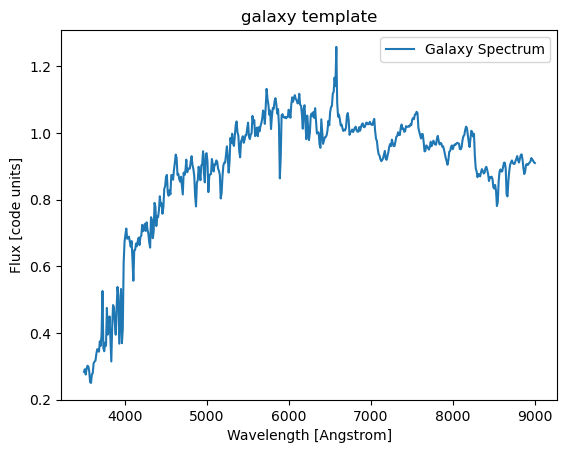

In [3]:
x = np.linspace(3500, 9000, 512)  # Wavelength range in Angstroms
g1 = galaxy_morph("Sa")

plt.title("galaxy template")
plt.plot(x, g1.gal_spec(x,1), label='Galaxy Spectrum')
plt.xlabel(r"Wavelength [Angstrom]")
plt.ylabel(r"Flux [code units]")
plt.legend(loc="best")

**Optical iron template model:**

The optical lines are velocity broadened. The available velocities range from 700 km s $^{-1}$ to 2800 km s $^{-1}$ in intervals of 100 km s $^{-1}$. 

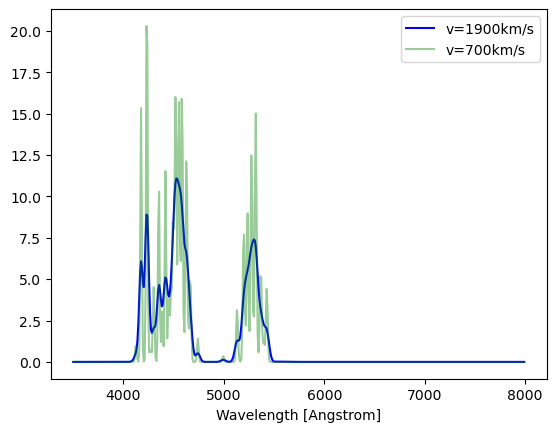

In [59]:
v1 = 1900
v2 = 700
S1 = iron_template_optical(v1)
S2 = iron_template_optical(v2)

plt.plot(x, S1.feII_temp_option1(x, 1.0), label=f"v={v1}km/s", color='b')
plt.plot(x, S2.feII_temp_option1(x, 1.0), label=f"v={v2}km/s", color='g', alpha=0.4)
plt.xlabel('Wavelength [Angstrom]')
plt.legend(loc="best")

#### **Simulate the total redshifted AGN spectrum:**

The function used here is **total_spectra_redshift** available through **AGNoptspecNN.simulator.simulator**

- This is a function for internal use while simulations but is exposed to the user.
- This functions is used internally to generate the fits spectrum. 
- These are the parameters:
    1. type : Type-1/Type-1.9
    2. z: redshift
    3. lmin: minimum wavelength: 3500 -- 4500 Angstrom 
    4. dlam: interval: depends on 
    5. npix: number of wavelength bins.

**Each time you run this cell a different AGN spectrum of distinct type would be randomly generated.**

Text(0.5, 0, 'Wavelength [Angstrom]')

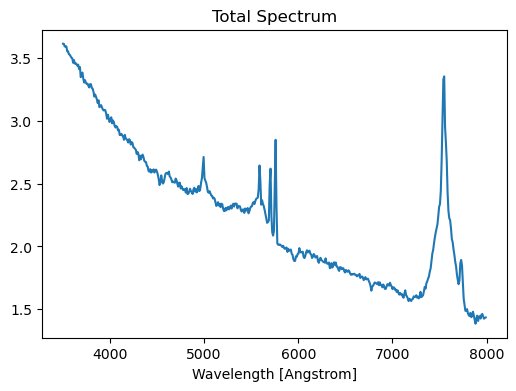

In [ ]:
z = 0.15
lmin = 3500.
npix = 500
dlam = 9.0

x, f1 = total_spectra_redshifted("Type-1", z, lmin, dlam, npix)

plt.figure(figsize=(6,4))
plt.title('Total Spectrum')
plt.plot(x , f1)
plt.xlabel('Wavelength [Angstrom]')

#### Simulating the spectrum and saving the file in fits format for training.

In [ ]:
def simulate_spectral_datasets(type, path, nsamples):
    """
    Simulator function
    """
    if type == "Type-1":
        destination_DIR = f"{path}/type1/"
        file_base = "specT0"
    elif type == "Type-1.9":
        destination_DIR = f"{path}/type1pt9/"
        file_base = "specT1"
    elif type == "Type-2":
        destination_DIR = f"{path}/type2/"
        file_base = "specT2"
    
    for i in range(nsamples):
        filename = f"{file_base}_no{i}.fits"
        sim.simulate_spectrum_optical(type, status="w", path=destination_DIR, filename=filename)
    return

**Simulation of optical spectra:**
We simulate the datasets type by type. This is fine for now. However, we shuffle the datasets for training purpose. Otherwise it can bias the training.

In [ ]:
path = "YOUR DIRECTORY"

simulate_spectral_datasets("Type-1"  , path, 5)
simulate_spectral_datasets("Type-1.9", path, 5)
simulate_spectral_datasets("Type-2"  , path, 5)

#### Check the simulated spectra

In [53]:
import os
import random as random

list_files  = os.listdir(f"{path}/type1pt9/")
file_chosen = random.choice(list_files)

print(file_chosen)

specT1_no1.fits


In [56]:
DAT = fits.open(f"{path}/type1pt9/{file_chosen}")
DAT[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   16 / length of dimension 1                          
NAXIS2  =                 5000 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    2 / number of table fields                         
TTYPE1  = 'wavelength'                                                          
TFORM1  = 'D       '                                                            
TTYPE2  = 'flux    '                                                            
TFORM2  = 'D       '                                                            
LABEL   = 'Type-1.9'        

Text(0, 0.5, 'Flux')

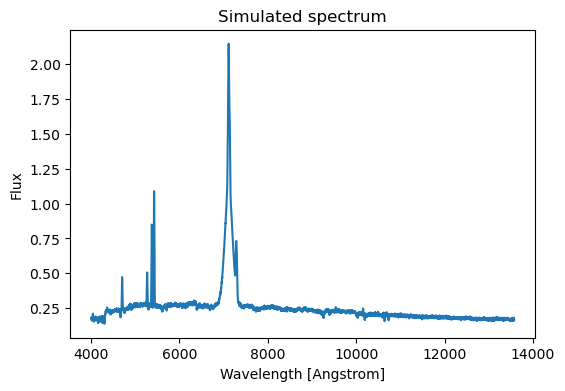

In [58]:
plt.figure(figsize=(6,4))
plt.title("Simulated spectrum")
plt.plot(DAT[1].data['wavelength'], DAT[1].data['flux'])
plt.xlabel("Wavelength [Angstrom]")
plt.ylabel("Flux")
